<a href="https://colab.research.google.com/github/hannaginther/ENGG680_2025_Fall/blob/Hanna/Project/Group_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **ENGG680 - Introduction to Digital Engineering**
## *Group Project: Implementing ML model for Hospital Length of Stay Prediction*

## Preliminary: Certificate of Work
### (5 Marks)

*We, the undersigned, certify that this is our own work, which has been done expressly for this course, either without the assistance of any other party or where appropriate we have acknowledged the work of others. Further, we have read and understood the section in the university calendar on plagiarism/cheating/other academic misconduct and we are aware of the implications thereof. We request that the total mark for this assignment be distributed as follows among group members:*

|          | First Name | Last Name | Signature (Full Name, Date) | Hours | Contribution % |
|----------|------------|-----------|-----------------------------|-------|----------------|
| Member 1: | Allison | Haynes | Signature, Date | hrs | 33.33% |
| Member 2: | Diya | Chakraborty | Signature, Date | hrs | 33.33% |
| Member 3: | Hanna | Ginther | Signature, Date | hrs | 33.33% |


##**Step #1: Data Cleaning & Preprocessing:**

#Import Libraries and Load Datasets

In [ ]:
from google.colab import drive
drive.mount ('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

In [84]:
sparcs_2024 = pd.read_csv('/content/drive/MyDrive/Sparcs_Datafiles/Hospital_Inpatient_Discharges_(SPARCS_De-Identified)__2024_20251029.csv')

/tmp/ipython-input-841084618.py:1: DtypeWarning: Columns (29) have mixed types. Specify dtype option on import or set low_memory=False.
  sparcs_2024 = pd.read_csv('/content/drive/MyDrive/Sparcs_Datafiles/Hospital_Inpatient_Discharges_(SPARCS_De-Identified)__2024_20251029.csv')


In [85]:
sparcs_2023 = pd.read_csv('/content/drive/MyDrive/Sparcs_Datafiles/Hospital_Inpatient_Discharges_(SPARCS_De-Identified)__2023_20251029.csv')

/tmp/ipython-input-1854978552.py:1: DtypeWarning: Columns (29) have mixed types. Specify dtype option on import or set low_memory=False.
  sparcs_2023 = pd.read_csv('/content/drive/MyDrive/Sparcs_Datafiles/Hospital_Inpatient_Discharges_(SPARCS_De-Identified)__2023_20251029.csv')


#Inspect Data Structure and Check Missing Values

In [86]:
sparcs_2023.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2125754 entries, 0 to 2125753
Data columns (total 33 columns):
 #   Column                               Dtype  
---  ------                               -----  
 0   Hospital Service Area                object 
 1   Hospital County                      object 
 2   Operating Certificate Number         float64
 3   Permanent Facility Id                float64
 4   Facility Name                        object 
 5   Age Group                            object 
 6   Zip Code - 3 digits                  object 
 7   Gender                               object 
 8   Race                                 object 
 9   Ethnicity                            object 
 10  Length of Stay                       object 
 11  Type of Admission                    object 
 12  Patient Disposition                  object 
 13  Discharge Year                       int64  
 14  CCSR Diagnosis Code                  object 
 15  CCSR Diagnosis Description      

In [87]:
sparcs_2024.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2196737 entries, 0 to 2196736
Data columns (total 33 columns):
 #   Column                               Dtype  
---  ------                               -----  
 0   Health Service Area                  object 
 1   Hospital County                      object 
 2   Operating Certificate Number         float64
 3   Permanent Facility Id                float64
 4   Facility Name                        object 
 5   Age Group                            object 
 6   Zip Code                             object 
 7   Gender                               object 
 8   Race                                 object 
 9   Ethnicity                            object 
 10  Length of Stay                       object 
 11  Type of Admission                    object 
 12  Patient Disposition                  object 
 13  Discharge Year                       int64  
 14  CCSR Diagnosis Code                  object 
 15  CCSR Diagnosis Description      

In [88]:
sparcs_2023.head()

,Hospital Service Area,Hospital County,Operating Certificate Number,Permanent Facility Id,Facility Name,Age Group,Zip Code - 3 digits,Gender,Race,Ethnicity,...,APR Severity of Illness Description,APR Risk of Mortality,APR Medical Surgical Description,Payment Typology 1,Payment Typology 2,Payment Typology 3,Birth Weight,Emergency Department Indicator,Total Charges,Total Costs
0,New York City,Bronx,7000006.0,3058.0,Montefiore Med Center - Jack D Weiler Hosp of ...,50 to 69,104,F,Other Race,Spanish/Hispanic,...,Moderate,Moderate,Medical,Medicaid,NaN,NaN,NaN,Y,"27,380.60","3,533.21"
1,New York City,Bronx,7000006.0,1168.0,Montefiore Medical Center-Wakefield Hospital,30 to 49,104,M,Black/African American,Not Span/Hispanic,...,Moderate,Minor,Medical,Medicaid,NaN,NaN,NaN,Y,"82,629.98","12,715.35"
2,New York City,Bronx,7000006.0,3058.0,Montefiore Med Center - Jack D Weiler Hosp of ...,50 to 69,104,M,Other Race,Not Span/Hispanic,...,Extreme,Extreme,Medical,Medicare,Medicaid,NaN,NaN,Y,"76,210.47","11,201.40"
3,New York City,Bronx,7000006.0,1169.0,Montefiore Medical Center - Henry & Lucy Moses...,18 to 29,104,M,Black/African American,Not Span/Hispanic,...,Moderate,Minor,Medical,Medicaid,NaN,NaN,NaN,Y,"77,532.60","13,872.77"
4,New York City,Bronx,7000006.0,1169.0,Montefiore Medical Center - Henry & Lucy Moses...,50 to 69,104,F,Other Race,Spanish/Hispanic,...,Major,Moderate,Medical,Medicare,Medicaid,NaN,NaN,Y,"63,430.29","10,249.28"


In [89]:
sparcs_2024.head()

,Health Service Area,Hospital County,Operating Certificate Number,Permanent Facility Id,Facility Name,Age Group,Zip Code,Gender,Race,Ethnicity,...,APR Severity of Illness Description,APR Risk of Mortality,APR Medical Surgical Description,Payment Typology 1,Payment Typology 2,Payment Typology 3,Birth Weight,Emergency Department Indicator,Total Charges,Total Costs
0,Hudson Valley,Westchester,5957001.0,1139.0,WESTCHESTER MEDICAL CENTER,0-17,OOS,F,White,Not Span/Hispanic,...,Moderate,Minor,Medical,Private Health Insurance,NaN,NaN,NaN,Y,46814.00,6772.07
1,New York City,Queens,7003001.0,1628.0,FLUSHING HOSPITAL MEDICAL CENTER,0-17,113,M,White,Spanish/Hispanic,...,Moderate,Moderate,Medical,Medicaid,NaN,NaN,NaN,Y,13490.00,15464.30
2,New York City,New York,7002054.0,1458.0,NEW YORK-PRESBYTERIAN HOSPITAL - NEW YORK WEIL...,70 or Older,100,M,White,Not Span/Hispanic,...,Moderate,Moderate,Medical,Medicare,Private Health Insurance,NaN,NaN,Y,49503.16,9324.77
3,New York City,New York,7002054.0,1464.0,NEW YORK-PRESBYTERIAN HOSPITAL - COLUMBIA PRES...,0-17,100,F,Other Race,Not Span/Hispanic,...,Minor,Minor,Medical,Private Health Insurance,NaN,NaN,2700,Y,27827.66,7304.27
4,New York City,New York,7002032.0,1466.0,MOUNT SINAI WEST,18-29,100,F,Other Race,Spanish/Hispanic,...,Moderate,Minor,Medical,Medicare,NaN,NaN,NaN,Y,32798.29,7948.10


In [90]:
#Drop hospital costs, emergency indicator, birth weight from both dataframes
sparcs_2023.drop(columns=['Total Costs', 'Emergency Department Indicator', 'Birth Weight', 'Operating Certificate Number'], inplace=True)
sparcs_2024.drop(columns=['Total Costs', 'Emergency Department Indicator', 'Birth Weight', 'Operating Certificate Number'], inplace=True)

In [91]:
#Change column names in sparcs_2023 to match 2024 DataFrame:
sparcs_2023.rename(columns={
    'Hospital Service Area':'Health Service Area',
    'Zip Code - 3 digits':'Zip Code'
}, inplace=True)

#Change dtype of charges column in sparcs_2023 to float64:
sparcs_2023['Total Charges'] = (sparcs_2023['Total Charges'].replace(',', '', regex=True).astype('float64'))

In [92]:
#Change dtype of APR DRG code, APR MDC code, APR severity of illness codes to objects
change_cols = [
    'Permanent Facility Id',
    'APR DRG Code',
    'APR MDC Code',
    'APR Severity of Illness Code'
]

#Function to convert APR code dtypes
def convert_apr_cols (df, change_cols):
  for col in change_cols:
    df[col] = df[col].astype('object')
  return df

# Apply to both datasets:
sparcs_2023 = convert_apr_cols(sparcs_2023, change_cols)
sparcs_2024 = convert_apr_cols(sparcs_2024, change_cols)

In [93]:
!pip install rapidfuzz

In [94]:
import re
from rapidfuzz import process, fuzz

# Define a function to preprocess strings for fuzzy matching
# STEP 1: convert all object dtypes to strings
sparcs_2023 = sparcs_2023.astype({col: 'string' for col in sparcs_2023.select_dtypes('object').columns})
sparcs_2024 = sparcs_2024.astype({col: 'string' for col in sparcs_2024.select_dtypes('object').columns})

# STEP 2: preprocessing function:
def clean_string(s):
  """
  Lowercase, remove punctuation, normalize whitespace.
  """
  if pd.isna(s):
    return ""
  s = str(s).lower()                    # lowercase
  s = re.sub(r'[^\w\s]', '', s)         # remove punctuation
  s = re.sub(r'\s+', ' ', s)            # normalize whitespace
  return s.strip()

# STEP 3: Fuzzy matching function for a single column with preprocessing
def fuzzy_match_column(df1, df2, column, threshold=50, scorer=fuzz.ratio):
  """
  Suggest best fuzzy string matches between df1[column] and df2[column] after preprocessing strings.

  Returns a DataFrame with matches and similarity scores above threshold.
  """
  # Unique values
  vals_2023 = df1[column].dropna().unique()
  vals_2024 = df2[column].dropna().unique()

  # Preprocess 2024 values for faster matching
  preprocessed_2024 = {v: clean_string(v) for v in vals_2024}

  matches = []
  for v in vals_2023:
    clean_v = clean_string(v)
    # Extract best match
    best_match = process.extractOne(
        clean_v,
        preprocessed_2024.values(),
        scorer=scorer
        )
    if best_match:
      matched_val, score, _ = best_match
      if score >= threshold:
        # Recover original 2024 string from preprocessed dict
        original_2024 = [k for k, val in preprocessed_2024.items() if val == matched_val][0]
      matches.append({
          'Column': column,
          '2023_value': v,
          '2024_best_match': original_2024,
          'Similarity_Score': score
      })
  return pd.DataFrame(matches)

In [95]:
# Def fuzzy matching function for all object columns:
def fuzzy_match_all_columns (df1, df2, object_columns, threshold=50, scorer=fuzz.ratio, output_csv="fuzzy_match_review.csv"):
  """
  fuzzy matching function for all columns with object dtype.

  Creates a csv file of matches with 50% or more similarity for review.
  """
  all_matches = []
  for col in object_columns:
    print(f"Processing column: {col}")
    matches_df = fuzzy_match_column(df1, df2, col, threshold, scorer)
    all_matches.append(matches_df)

  # Concatenate all results
  all_matches_df = pd.concat(all_matches, ignore_index=True)

  # Export to csv file
  all_matches_df.to_csv(output_csv, index=False)
  print(f"Fuzzy match results exported to: {output_csv}")
  return all_matches_df


# Function usage:
object_cols = [
    'Health Service Area',
    'Hospital County',
    'Permanent Facility Id',
    'Facility Name',
    'Age Group',
    'Zip Code',
    'Gender',
    'Race',
    'Ethnicity',
    'Type of Admission',
    'Patient Disposition',
    'CCSR Diagnosis Code',
    'CCSR Diagnosis Description',
    'CCSR Procedure Code',
    'CCSR Procedure Description',
    'APR DRG Code',
    'APR DRG Description',
    'APR MDC Code',
    'APR MDC Description',
    'APR Severity of Illness Code',
    'APR Severity of Illness Description',
    'APR Risk of Mortality',
    'APR Medical Surgical Description',
    'Payment Typology 1',
    'Payment Typology 2',
    'Payment Typology 3'
]

# Run full fuzzy matching and export csv
fuzzy_match_all_columns(
    sparcs_2023,
    sparcs_2024,
    object_cols,
    threshold=50,
    output_csv="sparcs_fuzzy_match_review.csv"
)

Processing column: Health Service Area
Processing column: Hospital County
Processing column: Permanent Facility Id
Processing column: Facility Name
Processing column: Age Group
Processing column: Zip Code
Processing column: Gender
Processing column: Race
Processing column: Ethnicity
Processing column: Type of Admission
Processing column: Patient Disposition
Processing column: CCSR Diagnosis Code
Processing column: CCSR Diagnosis Description
Processing column: CCSR Procedure Code
Processing column: CCSR Procedure Description
Processing column: APR DRG Code
Processing column: APR DRG Description
Processing column: APR MDC Code
Processing column: APR MDC Description
Processing column: APR Severity of Illness Code
Processing column: APR Severity of Illness Description
Processing column: APR Risk of Mortality
Processing column: APR Medical Surgical Description
Processing column: Payment Typology 1
Processing column: Payment Typology 2
Processing column: Payment Typology 3
Fuzzy match result

,Column,2023_value,2024_best_match,Similarity_Score
0,Health Service Area,New York City,New York City,100.0
1,Health Service Area,Hudson Valley,Hudson Valley,100.0
2,Health Service Area,Western NY,Western NY,100.0
3,Health Service Area,Finger Lakes,Finger Lakes,100.0
4,Health Service Area,Central NY,Central NY,100.0
...,...,...,...,...
2933,Payment Typology 3,Private Health Insurance,Private Health Insurance,100.0
2934,Payment Typology 3,Blue Cross/Blue Shield,Blue Cross/Blue Shield,100.0
2935,Payment Typology 3,"Managed Care, Unspecified","Managed Care, Unspecified",100.0
2936,Payment Typology 3,Miscellaneous/Other,Miscellaneous/Other,100.0


In [96]:
from google.colab import files
files.download('sparcs_fuzzy_match_review.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# @title
# Get common columns with object dtype
object_cols_2023 = sparcs_2023.select_dtypes(include='object').columns
object_cols_2024 = sparcs_2024.select_dtypes(include='object').columns
common_object_cols = list(set(object_cols_2023) & set(object_cols_2024))

# Iterate through common object columns and compare unique values
for col in common_object_cols:
  unique_2023 = set(sparcs_2023[col].unique())
  unique_2024 = set(sparcs_2024[col].unique())

  if unique_2023 != unique_2024:
    print(f"Differences found in column: {col}")
    print(f"Unique values in SPARCS 2023 but not in 2024: {list(unique_2023 - unique_2024)}")
    print(f"Unique values in SPARCS 2024 but not in 2023: {list(unique_2024 - unique_2023)}")
    print("-" * 30)

Differences found in column: Hospital County
Unique values in SPARCS 2023 but not in 2024: ['St Lawrence', 'Manhattan']
Unique values in SPARCS 2024 but not in 2023: ['Saint Lawrence', 'New York']
------------------------------
Differences found in column: Age Group
Unique values in SPARCS 2023 but not in 2024: ['0 to 17', '30 to 49', '18 to 29', '50 to 69']
Unique values in SPARCS 2024 but not in 2023: ['18-29', '0-17', '30-49', '50-69']
------------------------------
Differences found in column: APR Risk of Mortality
Unique values in SPARCS 2023 but not in 2024: [nan]
Unique values in SPARCS 2024 but not in 2023: ['Undetermined']
------------------------------
Differences found in column: APR Severity of Illness Description
Unique values in SPARCS 2023 but not in 2024: [nan]
Unique values in SPARCS 2024 but not in 2023: ['Undetermined']
------------------------------
Differences found in column: APR DRG Description
Unique values in SPARCS 2023 but not in 2024: ['SPLENECTOMY', 'OTHER 

In [ ]:
#Check for missing values, the % missing and display as a table
missing_data = []
for col in sparcs_2024.columns:
  missing_values = sparcs_2024[col].isnull().sum()
  missing_percent = (missing_values / len(sparcs_2024) * 100).round(2)
  missing_data.append({'Column': col, 'Missing Values': missing_values, 'Missing %': missing_percent})

missing_table = pd.DataFrame(missing_data)
display(missing_table)

In [ ]:
#Drop irrelevant columns

In [ ]:
#Impute missing continuous numerical values with median (where appropriate)...Or should imputation be based on median for specific diagnosis + treatment??

In [ ]:
#Impute missing categorical variables when appropriate

#Statistical Summary and Visualizing Outliers

In [ ]:
#Describe sparcs_2024 object variables
sparcs_2024.describe(include='object')

#Describe sparcs_2024 useful numerical variables
sparcs_2024.describe('Length of Stay', 'Total Charges', 'Total Costs')

In [ ]:
#Generate plots for outliers

In [ ]:
#Remove numerical outliers using IQR method?

In [ ]:
#Figure out how to remove categorical outliers

#Correlation Analysis

In [ ]:
# Defining a function to preprocess sparcs_2024 dataframe:
import pandas as pd
import numpy as np
import json

def preprocess_sparcs (df):
  """
  Comprehensive preprocessing for SPARCS dataset.

  Steps included:
  1. Handle missing values (NaN)
    - Categorical columns -> Replace with 'Unknown'
    - Continuous numeric columns -> Replace with median
    - Code/ID numeric columns -> Leave NaN (numeric) for now
  2. Build clinical code/description mappings + drop description columns
    - NaN replaced with placeholder in mapping dict
  3. Build Permanent Facility Id/Facility Name mapping + drop Facility Name column
    - NaN replaced with placeholder in mapping dict
  4. Drop unnecessary columns: Operating Certificate Number, birth weight
  5. Convert dtypes for ML
  """

  df = df.copy()  # Make a copy to avoid modifying original DataFrame:

  #---------------------------
  # Handle missing values first
  #---------------------------
  # Replace NaN in categorical columns with 'Unknown'
  categorical_cols = df.select_dtypes(include='object').columns.tolist()
  for col in categorical_cols:
    df[col] = df[col].fillna('Unknown')

  # Replace NaN in continuous numeric columns
  continuous_numeric_cols = ['Total Charges', 'Total Costs']  #Continuous values
  for col in continuous_numeric_cols:
    if col in df.columns:
      df[col] = df[col].fillna(df[col].median())

  #---------------------------
  # Clinical code/description columns mapping
  #---------------------------
  possible_code_cols = [col for col in df.columns if 'code' in col.lower()]
  exclude_terms = ['zip', 'postal', 'zip code', 'permanent facility id']
  code_cols = [col for col in possible_code_cols if not any (term in col.lower() for term in exclude_terms)]

  desc_cols = [col for col in df.columns if 'description' in col.lower()]

  code_mappings = {}
  mapped_desc_cols = []

  for code_col in code_cols:
    # Find corresponding description column
    desc_col = next((d for d in desc_cols if code_col.lower().replace('code', '') in d.lower()), None)
    if desc_col:
      # Temporarily replace NaN with placeholder for dictionary only
      temp_code_col = df[code_col].fillna(-1)
      temp_desc_col = df[desc_col].fillna('Unknown')

      # Create dictionary for mapping
      mapping_dict = dict(zip(temp_code_col, temp_desc_col))
      # Replace placeholder key with 'Unknown'
      mapping_dict = {k if k != -1 else 'Unknown': v for k, v in mapping_dict.items()}

      # Add mapping to dictionary
      code_mappings[code_col] = mapping_dict

      # Append mapped description column to list
      mapped_desc_cols.append(desc_col)

  #Drop mapped description columns
  df.drop(columns=mapped_desc_cols, inplace=True)

  #---------------------------
  # Permanent Facility ID/Facility Name columns mapping
  #---------------------------
  facility_mapping = {}
  if 'Permanent Facility Id' in df.columns and 'Facility Name' in df.columns:
    # Temporarily replace NaN with placeholder for dictionary only
    temp_facility_id = df['Permanent Facility Id'].fillna(-1)
    temp_facility_name = df['Facility Name'].fillna('Unknown')

    # Create dictionary for mapping
    facility_mapping = dict(zip(temp_facility_id, temp_facility_name))
    # Replace placeholder key with 'Unknown'
    facility_mapping = {k if k != -1 else 'Unknown': v for k, v in facility_mapping.items()}
    # Drop Facility Name column from DataFram
    df.drop(columns=['Facility Name'], inplace=True)

  #---------------------------
  # Drop Operating Certificate Number column
  #---------------------------
  unnecessary_cols = ['Operatng Certificate Number', 'Birth Weight']
  for col in unnecessary_cols:
    if col in df.columns:
      df.drop(columns=[col], inplace=True)

  #---------------------------
  # Convert data types for ML
  #---------------------------

  # Categorical columns:
  for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype('category')

  # Continuous numeric columns:
  for col in continuous_numeric_cols:
    if col in df.columns:
      df[col] = df[col].astype('float32')

  # Identifier / code numeric columns -> category:
  id_code_cols = [
      'Discharge Year', 'APR DRG Code', 'APR MDC Code', 'APR Severity of Illness Code', 'Permanent Facility Id'
  ]

  for col in id_code_cols:
    if col in df.columns:
      df[col] = df[col].astype('category')

  return df, code_mappings, facility_mapping

In [ ]:
  # Using Preprocessing function

  sparcs_2024_cleaned, sparcs_2024_code_mappings, sparcs_2024_facility_mapping = preprocess_sparcs(sparcs_2024)

  print ("Columns after preprocessing: ", sparcs_2024_cleaned.columns.tolist())
  print ("Sample clinical code mappings: ", json.dumps(dict(list(sparcs_2024_code_mappings.items())[:5], indent=2)))
  print ("Sample permanent facility mappings: ", json.dumps(dict(list(sparcs_2024_facility_mapping.items())[:5], indent=2)))


Columns after preprocessing:  ['Health Service Area', 'Hospital County', 'Operating Certificate Number', 'Permanent Facility Id', 'Age Group', 'Zip Code', 'Gender', 'Race', 'Ethnicity', 'Length of Stay', 'Type of Admission', 'Patient Disposition', 'Discharge Year', 'CCSR Diagnosis Code', 'CCSR Procedure Code', 'APR DRG Code', 'APR MDC Code', 'APR Severity of Illness Code', 'APR Risk of Mortality', 'APR Medical Surgical Description', 'Payment Typology 1', 'Payment Typology 2', 'Payment Typology 3', 'Emergency Department Indicator', 'Total Charges', 'Total Costs']
Sample clinical code mappings:  {"CCSR Diagnosis Code": {"SYM002": "FEVER", "RSP009": "ASTHMA", "END009": "OBESITY", "SYM001": "SYNCOPE", "EYE003": "GLAUCOMA", "PNL001": "LIVEBORN", "SYM005": "DYSPHAGIA", "GEN009": "HEMATURIA", "RSP003": "INFLUENZA", "NVS001": "MENINGITIS", "NVS018": "MYOPATHIES", "INF002": "SEPTICEMIA", "NVS014": "CNS ABSCESS", "DIG014": "HEMORRHOIDS", "CIR031": "HYPOTENSION", "GEN010": "PROTEINURIA", "MUS013"

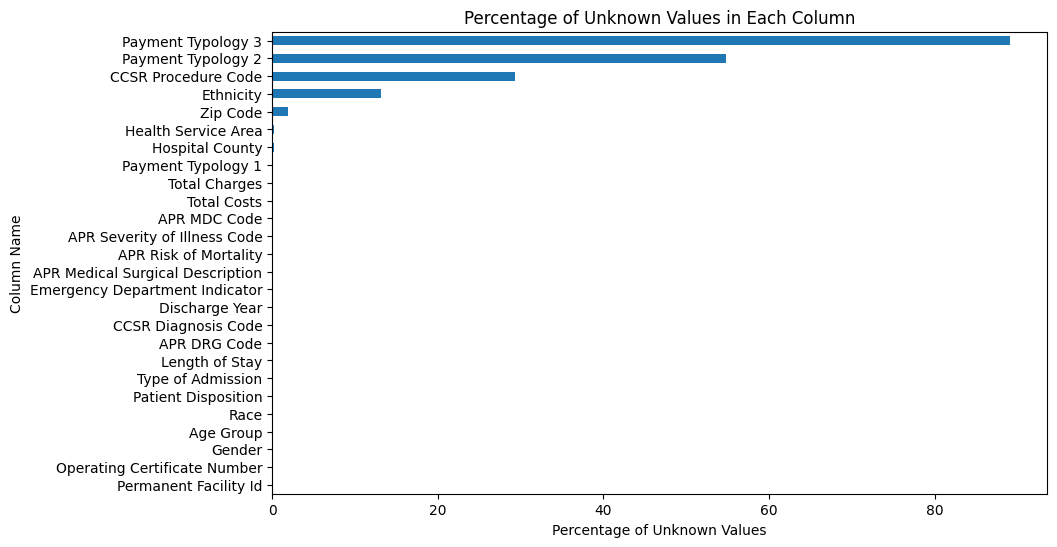

In [ ]:
import matplotlib.pyplot as plt

unknown_counts = sparcs_2024_cleaned.apply(lambda col: (col == 'Unknown').sum())
unknown_percents = unknown_counts / len(sparcs_2024_cleaned) * 100

plt.figure(figsize=(10, 6))
unknown_percents.sort_values(ascending=True).plot(kind='barh')
plt.xlabel('Percentage of Unknown Values')
plt.ylabel('Column Name')
plt.title('Percentage of Unknown Values in Each Column')
plt.show()